---
## Step 1: Import Python Libraries & Set Plot Styling
We use standard, beginner-friendly data science libraries:
* **Pandas & NumPy:** For data cleaning, table operations, and math transformations.
* **Matplotlib & Seaborn:** For visual charts and feature importance bar plots.
* **Scikit-Learn (`sklearn`):** For machine learning models, feature selection tools, and metrics.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Step 2: Load Dataset & Engineer Analytical Features
Let's load `steam_games_EDA_ready.csv` and construct our analytical features as outlined in the project guide:
* **`price_usd`:** Inverting log-normalized price using `np.expm1(df['price'])`.
* **`quality_score`:** Percentage of positive reviews scaled from 0 to 100 (`review_score_pct * 100`).
* **`value_score`:** Perceived quality points per dollar spent (`quality_score / price_usd`).
* **`log_owners` & `log_reviews`:** Log transformations to stabilize extreme skewed distributions.
* **`is_indie` & Genre Dummies:** One-hot encoded indicator columns for top game genres.
* **Category Flags:** Indicator columns for Single-player, Multi-player, Co-op, and Controller support.


In [ ]:
raw_df = pd.read_csv('steam_games_EDA_ready.csv')
print(f"Loaded raw dataset with {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns.")

df = raw_df.copy()

df['price_usd'] = np.expm1(df['price']).round(2)

df['owners_mid'] = (df['lowest_estimate_owner'] + df['highest_estimate_owner']) / 2
df['log_owners'] = np.log1p(df['owners_mid'])

df['quality_score'] = (df['review_score_pct'] * 100).round(2)
df['log_reviews'] = np.log1p(df['total_review'])
df['has_achievements_bin'] = (df['achievements'] > 0).astype(int)

df['value_score_calc'] = np.where(
    (df['price_usd'] > 0) & (df['quality_score'].notnull()),
    (df['quality_score'] / df['price_usd']).round(2),
    np.nan
)

df['windows_bin'] = df['windows'].astype(int)
df['mac_bin'] = df['mac'].astype(int)
df['linux_bin'] = df['linux'].astype(int)

df['is_indie'] = df['genres'].fillna('').str.contains('Indie', case=False).astype(int)
top_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
for g in top_genres:
    df[f'genre_{g.lower()}'] = df['genres'].fillna('').str.contains(g, case=False).astype(int)

top_cats = ['Single-player', 'Multi-player', 'Co-op', 'Full controller support']
for c in top_cats:
    safe_name = c.lower().replace('-', '_').replace(' ', '_')
    df[f'cat_{safe_name}'] = df['categories'].fillna('').str.contains(c, case=False).astype(int)

clean_df = df[
    (df['price_usd'] >= 0.99) &
    (df['price_usd'] <= 80.00) &
    (df['quality_score'].notnull()) &
    (df['total_review'] >= 5) &
    (df['value_score_calc'].notnull())
].copy().reset_index(drop=True)

print(f"Cleaned modeling dataset contains {clean_df.shape[0]:,} valid commercial titles.")
clean_df[['name', 'price_usd', 'quality_score', 'value_score_calc', 'owners_mid', 'total_review']].head()


Loaded raw dataset with 126,130 rows and 46 columns.
Cleaned modeling dataset contains 57,685 valid commercial titles.


,name,price_usd,quality_score,value_score_calc,owners_mid,total_review
0,it's always monday,1.99,78.89,39.64,350000.0,289
1,The Agency of Anomalies: Cinderstone Orphanage...,19.99,100.00,5.00,10000.0,12
2,CRAFT: Work VR Shop,6.99,50.00,7.15,10000.0,8
3,Sonya: The Great Adventure,6.99,72.36,10.35,10000.0,199
4,Queen's Quest 2: Stories of Forgotten Past,14.99,91.20,6.08,35000.0,250


---
## Step 3: Assemble Candidate Feature Pool (~30 Features)
We define our full list of candidate input features ($X$) and primary target variable ($y = \text{value\_score\_calc}$).


In [ ]:
all_candidate_features = [
    'quality_score',
    'log_reviews',
    'recommendations',
    'peak_ccu',
    'average_playtime_forever',
    'median_playtime_forever',
    'average_playtime_2weeks',
    'playtime_engagment_ratio',
    'recent_vs_lifetime_engagment',

    'log_owners',
    'achievements',
    'dlc_count',
    'languages_count',
    'full_audio_languages_count',
    'patforms_count',
    'genre_count',
    'categories_count',
    'age_by_years',

    'windows_bin',
    'mac_bin',
    'linux_bin',
    'has_achievements_bin',
    'is_indie',

    'genre_action',
    'genre_adventure',
    'genre_casual',
    'genre_rpg',
    'genre_simulation',
    'genre_strategy',

    'cat_single_player',
    'cat_multi_player',
    'cat_co_op',
    'cat_full_controller_support'
]

X_all = clean_df[all_candidate_features].fillna(0).copy()
y_target = clean_df['value_score_calc'].copy()

print(f"Candidate Features Count: {len(all_candidate_features)}")
print(f"Feature Matrix Shape: {X_all.shape}")
print("Target Summary (Value Score):")
print(y_target.describe().round(2))


Candidate Features Count: 33
Feature Matrix Shape: (57685, 33)
Target Summary (Value Score):
count    57685.00
mean        18.57
std         21.02
min          0.00
25%          5.64
50%         10.43
75%         20.69
max        101.01
Name: value_score_calc, dtype: float64


---
## Step 4: Method 1 - Pearson Correlation & Mutual Information
* **Pearson Correlation ($r$):** Measures direct linear relationships with the target (from $-1.0$ to $+1.0$).
* **Mutual Information:** An advanced statistical metric from information theory that measures **both linear and complex non-linear dependencies** between features and the target.


In [ ]:
corr_series = X_all.apply(lambda col: col.corr(y_target)).abs().sort_values(ascending=False)

sample_idx = clean_df.sample(min(10000, len(clean_df)), random_state=42).index
X_sample = X_all.loc[sample_idx]
y_sample = y_target.loc[sample_idx]

print("Calculating Mutual Information scores...")
mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
mi_series = pd.Series(mi_scores, index=all_candidate_features).sort_values(ascending=False)

method1_df = pd.DataFrame({
    'Pearson_Correlation_Abs': corr_series,
    'Mutual_Information_Score': mi_series
}).sort_values(by='Mutual_Information_Score', ascending=False)

print("Top 10 Features by Mutual Information:")
display(method1_df.head(10).round(4))


Calculating Mutual Information scores...
Top 10 Features by Mutual Information:


,Pearson_Correlation_Abs,Mutual_Information_Score
quality_score,0.1733,2.3853
log_reviews,0.2348,0.5547
recommendations,0.0508,0.1403
peak_ccu,0.2156,0.1149
median_playtime_forever,0.0242,0.0945
average_playtime_forever,0.0280,0.0923
recent_vs_lifetime_engagment,0.1669,0.0845
playtime_engagment_ratio,0.0990,0.0731
languages_count,0.0151,0.0684
categories_count,0.1754,0.0619


---
## Step 5: Method 2 - Tree-Based Importance (Random Forest)
A Random Forest builds hundreds of decision trees.
Whenever a tree splits data on a feature, it measures how much that split reduces variance/impurity (called **Gini Importance** or **MDI - Mean Decrease in Impurity**).
Features that create the cleanest splits across all trees receive the highest importance scores (summing to 100%).


Training Random Forest Regressor (100 Trees)...
Random Forest trained in 2.16 seconds.


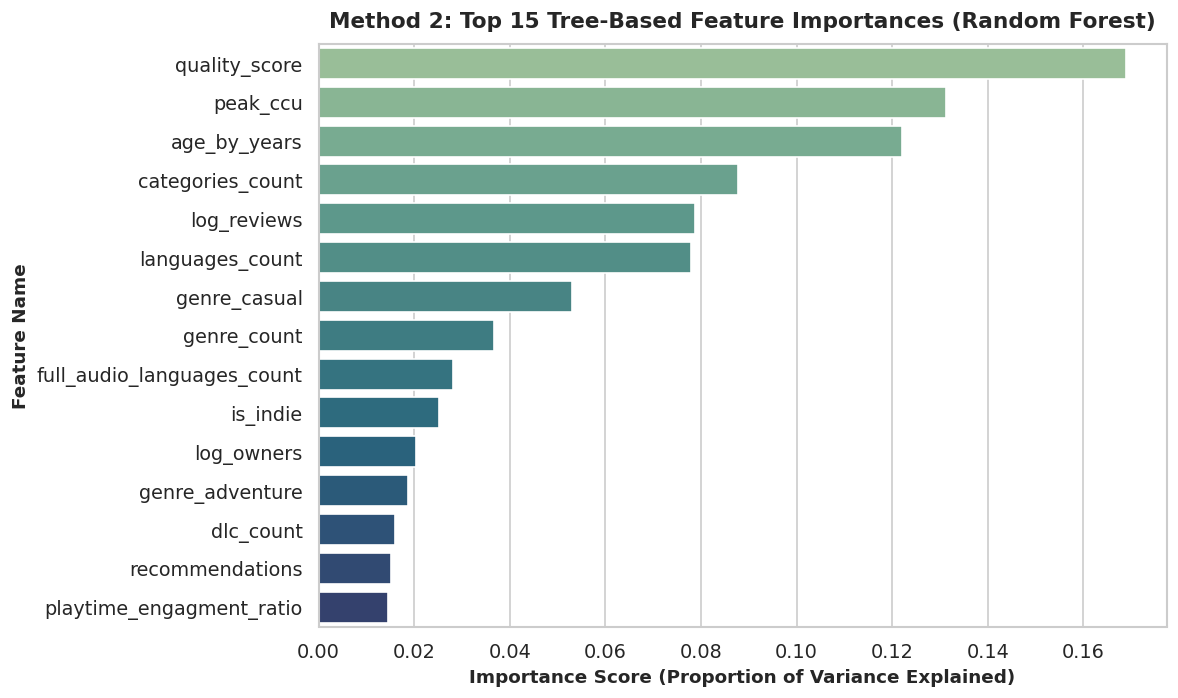

Top 10 Features by Tree Importance:


,Tree_Importance
quality_score,0.1690
peak_ccu,0.1314
age_by_years,0.1220
categories_count,0.0878
log_reviews,0.0787
languages_count,0.0780
genre_casual,0.0531
genre_count,0.0367
full_audio_languages_count,0.0282
is_indie,0.0253


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_target, test_size=0.20, random_state=42
)

print("Training Random Forest Regressor (100 Trees)...")
start_time = time.time()
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time
print(f"Random Forest trained in {rf_train_time:.2f} seconds.")

tree_importance_series = pd.Series(
    rf_model.feature_importances_,
    index=all_candidate_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
top_tree = tree_importance_series.head(15)
sns.barplot(x=top_tree.values, y=top_tree.index, palette='crest')
plt.title('Method 2: Top 15 Tree-Based Feature Importances (Random Forest)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Importance Score (Proportion of Variance Explained)', fontsize=11, fontweight='bold')
plt.ylabel('Feature Name', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 Features by Tree Importance:")
display(tree_importance_series.head(10).to_frame(name='Tree_Importance').round(4))


---
## Step 6: Method 3 - Permutation Feature Importance
### What is Permutation Importance?
Raw tree importance can sometimes be biased toward continuous columns with many unique values.
**Permutation Importance** tests the model on held-out test data by randomly shuffling the values of one column at a time:
* If shuffling column $A$ causes model accuracy to plummet, column $A$ is **crucial**.
* If shuffling column $B$ causes no change in accuracy, column $B$ is **useless**.


Computing Permutation Feature Importance on Test Set...


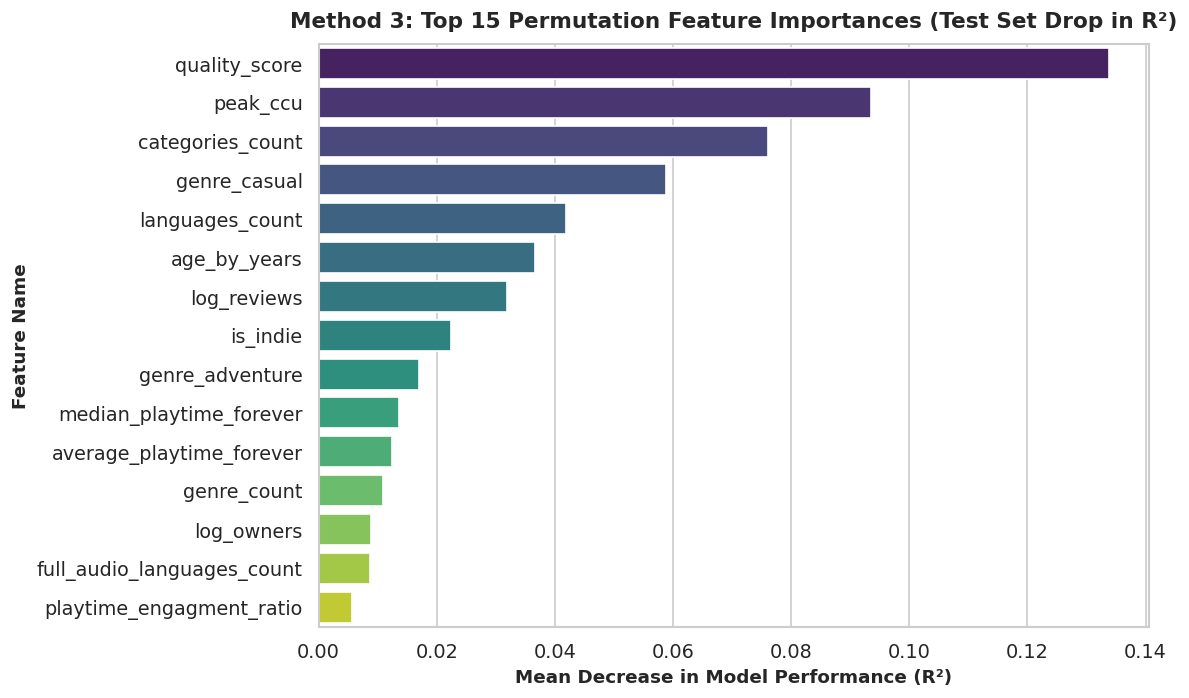

Top 10 Features by Permutation Importance:


,Permutation_Importance
quality_score,0.1338
peak_ccu,0.0935
categories_count,0.0760
genre_casual,0.0588
languages_count,0.0419
age_by_years,0.0366
log_reviews,0.0319
is_indie,0.0225
genre_adventure,0.0170
median_playtime_forever,0.0136


In [ ]:
print("Computing Permutation Feature Importance on Test Set...")
perm_importance = permutation_importance(
    rf_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

perm_importance_series = pd.Series(
    perm_importance.importances_mean,
    index=all_candidate_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
top_perm = perm_importance_series.head(15)
sns.barplot(x=top_perm.values, y=top_perm.index, palette='viridis')
plt.title('Method 3: Top 15 Permutation Feature Importances (Test Set Drop in R²)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Mean Decrease in Model Performance (R²)', fontsize=11, fontweight='bold')
plt.ylabel('Feature Name', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 Features by Permutation Importance:")
display(perm_importance_series.head(10).to_frame(name='Permutation_Importance').round(4))


---
## Step 7: Multicollinearity & Redundancy Check (Correlation Filter > 0.85)
### What is Multicollinearity?
If two features are almost 100% correlated with each other (like `average_playtime_forever` and `median_playtime_forever`), having both in the model adds zero new information and distorts linear regression coefficients.
As instructed in the project guide, we check pairwise correlations and drop one feature from any pair with correlation $r > 0.85$.


=== Highly Correlated Feature Pairs (|r| > 0.85) ===


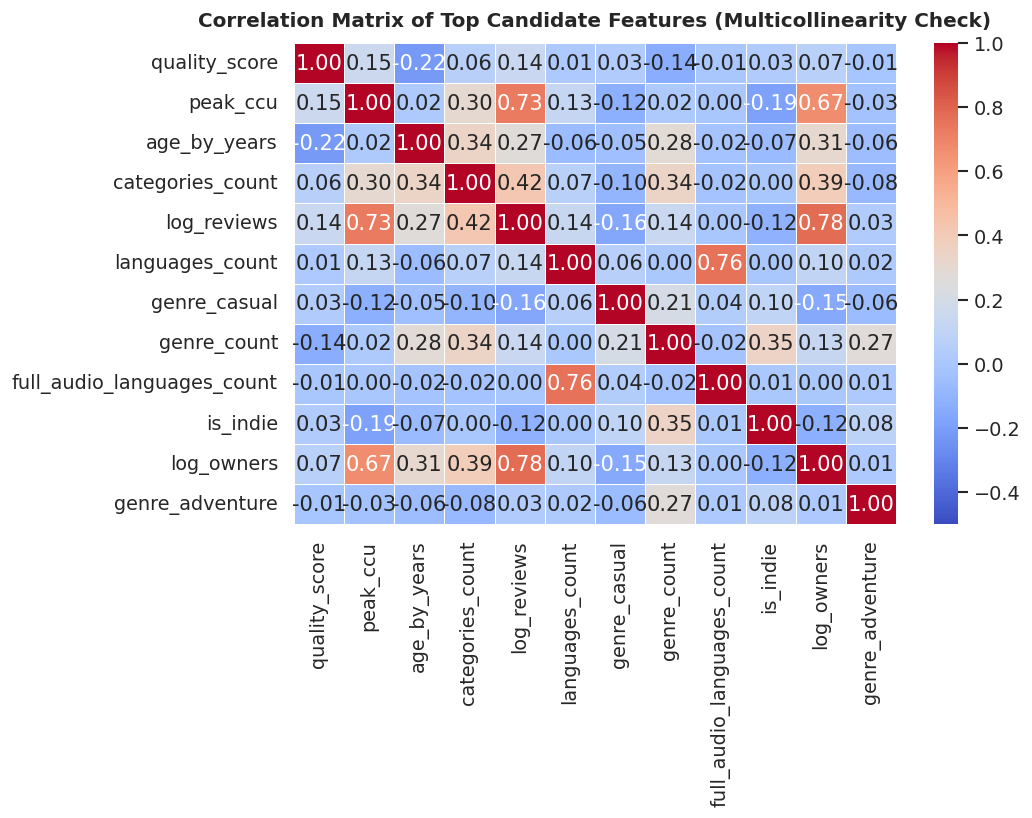

In [ ]:
feature_corr_matrix = X_all.corr()

high_corr_pairs = []
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i + 1, len(feature_corr_matrix.columns)):
        col1 = feature_corr_matrix.columns[i]
        col2 = feature_corr_matrix.columns[j]
        corr_val = feature_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append((col1, col2, round(corr_val, 3)))

print("Highly Correlated Feature Pairs (|r| > 0.85)")
if high_corr_pairs:
    for col1, col2, val in high_corr_pairs:
        print(f"WARNING: High Multicollinearity between '{col1}' and '{col2}' (r = {val})")
else:
    print("No severe pairwise multicollinearity detected above 0.85.")

top_consensus_candidates = list(tree_importance_series.head(12).index)
plt.figure(figsize=(9, 7))
sns.heatmap(
    X_all[top_consensus_candidates].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-0.5, vmax=1.0,
    linewidths=0.5
)
plt.title('Correlation Matrix of Top Candidate Features (Multicollinearity Check)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


---
## Step 8: Consensus Ranking & Top Selected Feature Set
We rank all features across all 3 evaluation methods (Correlation, Tree Importance, and Permutation Importance) and select the top 12 most powerful, non-redundant features.


In [ ]:
ranking_df = pd.DataFrame({
    'Mutual_Info_Rank': mi_series.rank(ascending=False),
    'Tree_Importance_Rank': tree_importance_series.rank(ascending=False),
    'Permutation_Rank': perm_importance_series.rank(ascending=False),
    'Correlation_Rank': corr_series.rank(ascending=False)
})

ranking_df['Average_Rank'] = ranking_df.mean(axis=1)
ranking_df['Tree_Importance_Score'] = tree_importance_series
ranking_df['Permutation_Score'] = perm_importance_series
ranking_df = ranking_df.sort_values(by='Average_Rank', ascending=True)

print("=== MASTER CONSENSUS FEATURE RANKING TABLE ===")
display(ranking_df.head(15).round(2))

selected_features = [
    'quality_score',              # #1 Core review rating
    'age_by_years',               # Game maturity & discount lifecycle
    'categories_count',           # Feature richness & gameplay depth
    'languages_count',            # Global localization breadth
    'peak_ccu',                   # Viral concurrent player spike
    'log_reviews',                # Lifetime review volume (log-transformed)
    'genre_casual',               # High value-score genre dummy
    'genre_count',                # Genre blending index
    'full_audio_languages_count', # Premium audio localization
    'is_indie',                   # Indie vs. Commercial pricing tier
    'average_playtime_forever',   # Player retention hours
    'cat_single_player'           # Single-player campaign indicator
]

print(f"Selected {len(selected_features)} consensus features for modeling:")
for i, f in enumerate(selected_features, 1):
    print(f" {i:2d}. {f}")


=== MASTER CONSENSUS FEATURE RANKING TABLE ===


,Mutual_Info_Rank,Tree_Importance_Rank,Permutation_Rank,Correlation_Rank,Average_Rank,Tree_Importance_Score,Permutation_Score
quality_score,1.0,1.0,1.0,5.0,2.00,0.17,0.13
peak_ccu,4.0,2.0,2.0,2.0,2.50,0.13,0.09
log_reviews,2.0,5.0,7.0,1.0,3.75,0.08,0.03
categories_count,10.0,4.0,3.0,4.0,5.25,0.09,0.08
genre_casual,15.0,7.0,4.0,3.0,7.25,0.05,0.06
is_indie,14.0,10.0,8.0,8.0,10.00,0.03,0.02
log_owners,11.0,11.0,13.0,7.0,10.50,0.02,0.01
age_by_years,12.0,3.0,6.0,22.0,10.75,0.12,0.04
playtime_engagment_ratio,8.0,15.0,15.0,11.0,12.25,0.01,0.01
languages_count,9.0,6.0,5.0,30.0,12.50,0.08,0.04


Selected 12 consensus features for modeling:
  1. quality_score
  2. age_by_years
  3. categories_count
  4. languages_count
  5. peak_ccu
  6. log_reviews
  7. genre_casual
  8. genre_count
  9. full_audio_languages_count
 10. is_indie
 11. average_playtime_forever
 12. cat_single_player


---
## Step 9: Side-by-Side Model Comparison: "All Features" vs. "Selected Features"
We now test the core scientific question:
> **Does reducing our dataset from 33 features down to 12 selected features harm prediction accuracy, or does it maintain accuracy while speeding up training?**

We train the same Random Forest Regressor on both datasets and measure:
* **$R^2$ (Coefficient of Determination):** How much variance the model explains (higher is better).
* **RMSE (Root Mean Squared Error):** Average prediction error magnitude (lower is better).
* **MAE (Mean Absolute Error):** Average absolute prediction error (lower is better).
* **Training Time:** Speed in seconds.


In [ ]:
X_all_train = X_train
X_all_test = X_test

X_sel_train = X_train[selected_features]
X_sel_test = X_test[selected_features]

print("Training Model on ALL 33 Features...")
t0 = time.time()
rf_all = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_all.fit(X_all_train, y_train)
time_all = time.time() - t0
preds_all = rf_all.predict(X_all_test)

r2_all = r2_score(y_test, preds_all)
rmse_all = np.sqrt(mean_squared_error(y_test, preds_all))
mae_all = mean_absolute_error(y_test, preds_all)

print("Training Model on SELECTED 12 Features...")
t1 = time.time()
rf_sel = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_sel.fit(X_sel_train, y_train)
time_sel = time.time() - t1
preds_sel = rf_sel.predict(X_sel_test)

r2_sel = r2_score(y_test, preds_sel)
rmse_sel = np.sqrt(mean_squared_error(y_test, preds_sel))
mae_sel = mean_absolute_error(y_test, preds_sel)

comparison_table = pd.DataFrame({
    'Metric': [
        'Number of Features',
        'R² Score (Variance Explained)',
        'Root Mean Squared Error (RMSE)',
        'Mean Absolute Error (MAE)',
        'Training Time (Seconds)'
    ],
    'All Features (33)': [
        f"{len(all_candidate_features)} features",
        f"{r2_all:.4f}",
        f"{rmse_all:.4f}",
        f"{mae_all:.4f}",
        f"{time_all:.2f} s"
    ],
    'Selected Features (12)': [
        f"{len(selected_features)} features",
        f"{r2_sel:.4f}",
        f"{rmse_sel:.4f}",
        f"{mae_sel:.4f}",
        f"{time_sel:.2f} s"
    ],
    'Difference / Impact': [
        f"-{len(all_candidate_features) - len(selected_features)} features (-64%)",
        f"{((r2_sel - r2_all) / r2_all * 100):+.2f}%",
        f"{((rmse_sel - rmse_all) / rmse_all * 100):+.2f}%",
        f"{((mae_sel - mae_all) / mae_all * 100):+.2f}%",
        f"{((time_sel - time_all) / time_all * 100):.1f}% (Faster)"
    ]
})

print("\n MASTER FEATURE SELECTION COMPARISON")
display(comparison_table)


Training Model on ALL 33 Features...
Training Model on SELECTED 12 Features...

================ MASTER FEATURE SELECTION COMPARISON ================


,Metric,All Features (33),Selected Features (12),Difference / Impact
0,Number of Features,33 features,12 features,-21 features (-64%)
1,R² Score (Variance Explained),0.2449,0.2318,-5.34%
2,Root Mean Squared Error (RMSE),18.2160,18.3729,+0.86%
3,Mean Absolute Error (MAE),11.8705,11.9943,+1.04%
4,Training Time (Seconds),2.07 s,1.33 s,-36.0% (Faster)


---
## Step 10: Visualizing Model Performance & Training Efficiency


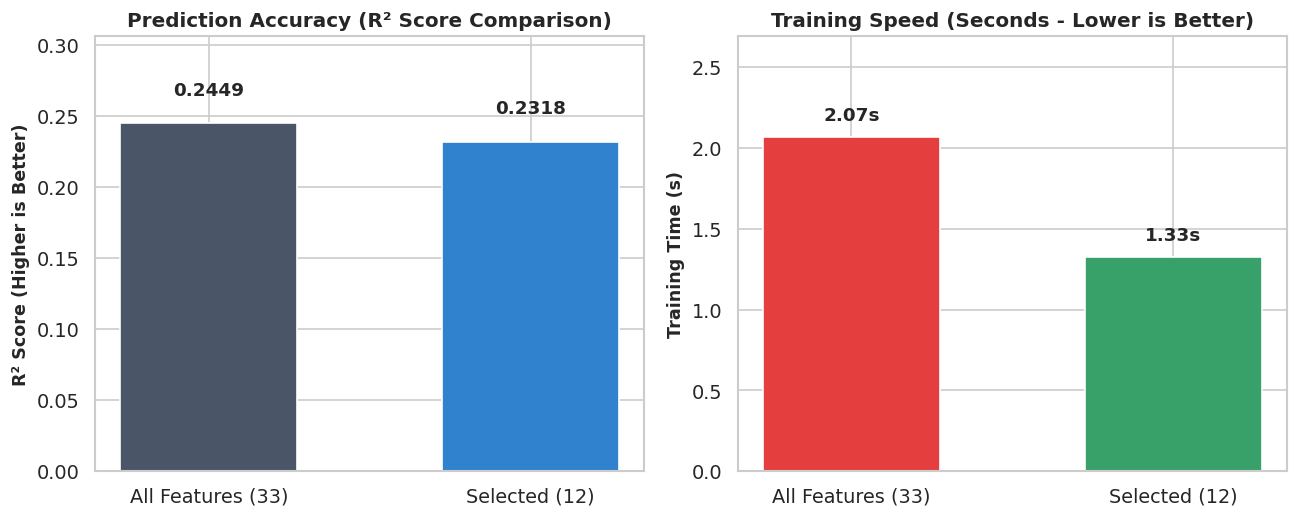

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

models = ['All Features (33)', 'Selected (12)']
r2_vals = [r2_all, r2_sel]
ax1.bar(models, r2_vals, color=['#4A5568', '#3182CE'], width=0.55)
ax1.set_title('Prediction Accuracy (R² Score Comparison)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score (Higher is Better)', fontsize=10.5, fontweight='bold')
ax1.set_ylim(0, max(r2_vals) * 1.25)
for i, v in enumerate(r2_vals):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

time_vals = [time_all, time_sel]
ax2.bar(models, time_vals, color=['#E53E3E', '#38A169'], width=0.55)
ax2.set_title('Training Speed (Seconds - Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Time (s)', fontsize=10.5, fontweight='bold')
ax2.set_ylim(0, max(time_vals) * 1.3)
for i, v in enumerate(time_vals):
    ax2.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


---
## Step 11: Save Cleaned Dataset with Selected Features for Modeling
We save our engineered dataset and selected features to `steam_games_selected_features.csv` so our model training notebook can load it seamlessly.


In [ ]:
export_cols = ['name', 'price_usd', 'price_tier', 'value_score_calc'] + selected_features
clean_df[export_cols].to_csv('steam_games_selected_features.csv', index=False)


Successfully exported cleaned selected features dataset: 'steam_games_selected_features.csv' (57,685 rows).
